# 05 · Monte Carlo y cuotas del Clásico

### De un partido posible a 10,000 escenarios

Este notebook reconstruye una simulación **prepartido** del Barcelona–Real Madrid del 11 de mayo de 2025. El resultado real se mantiene fuera del modelo y solo se revela al final.

Cada escenario avanza minuto a minuto. La intensidad ofensiva se adapta al reloj y a lo que está ocurriendo en esa trayectoria; después se generan ocasiones con Poisson y cada ocasión se convierte o no en gol según su xG. La semilla `28055` hace que las 10,000 simulaciones sean reproducibles.

In [1]:
from collections import Counter, defaultdict
from itertools import product
from pathlib import Path
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from patsy import dmatrix
import xgboost as xgb
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"

plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "font.size": 11.5, "axes.titleweight": "bold",
})

def clean_axes(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

def finish_chart(fig, subtitle, y=0.93):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")
    fig.text(0.975, 0.975, "✦", fontsize=17, color=GOLD, ha="right", va="top")

data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró 02_data")
ROOT_DIR = DATA_DIR.parent
ASSET_DIR = ROOT_DIR / "01_assets"
ASSET_DIR.mkdir(exist_ok=True)

MATCH_ID = 28055
MATCH_DATE = pd.Timestamp("2025-05-11")
SEED = 28055
N_SIMS = 10_000
MEAN_XG_SHOT = 0.10

context = pd.read_csv(DATA_DIR / "contextual_rag.csv", encoding="utf-8-sig")
context["date"] = pd.to_datetime(context["date"])
segments = pd.read_csv(DATA_DIR / "clasico_contextual_segments.csv", encoding="utf-8-sig")
subs = pd.read_csv(DATA_DIR / "substitutions_barca_real_madrid.csv", encoding="utf-8-sig")
subs["match_date"] = pd.to_datetime(subs["match_date"])
predictions = pd.read_excel(DATA_DIR / "predictions.xlsx")

clasico = subs[subs["match_id"] == MATCH_ID].copy()
history = subs[subs["match_date"] < MATCH_DATE].copy()

In [2]:
required_sub_columns = {
    "match_id", "match_date", "team", "player_id", "sub_in", "sub_out",
    "match_minutes_played", "in_status", "out_status", "off_xg_coef",
    "def_xg_coef", "fatigue", "rhythm",
}
assert required_sub_columns.issubset(subs.columns)
assert not subs.duplicated(["match_id", "player_id"]).any()
assert set(clasico["team"]) == {"Barcelona", "Real Madrid"}
assert len(clasico) == 44
assert context[context["match_id"] == MATCH_ID].shape[0] > 0
assert MATCH_ID not in set(predictions.get("match_id", pd.Series(dtype=int)).dropna().astype(int))

def match_pools(team):
    rows = clasico[clasico["team"] == team]
    starters = rows.loc[
        rows["sub_in"].isna() & (rows["match_minutes_played"] > 0), "player_id"
    ].tolist()
    bench = rows.loc[~rows["player_id"].isin(starters), "player_id"].tolist()
    return starters, bench

home_starters, home_bench = match_pools("Barcelona")
away_starters, away_bench = match_pools("Real Madrid")
assert len(home_starters) == len(away_starters) == 11

In [3]:
EXPECTED_FEATURES = [
    "elevation_dif", "travel", "is_home",
    "match_state_-0.5", "match_state_-1.5", "match_state_0.0",
    "match_state_0.5", "match_state_1.5",
    "player_dif_-0.5", "player_dif_-1.5", "player_dif_0.0",
    "player_dif_0.5", "player_dif_1.5",
    "time_segment_1", "time_segment_2", "time_segment_3",
    "time_segment_4", "time_segment_5", "time_segment_6",
]

booster = xgb.Booster()
booster.load_model(DATA_DIR / "crag_booster.json")
assert booster.feature_names == EXPECTED_FEATURES

clasico_context = context[context["match_id"] == MATCH_ID].sort_values("first_segment_id")
meta = clasico_context.iloc[0]
first_segment = segments.sort_values("segment_id").iloc[0]
HOME_FR_START = first_segment["teamA_fr_rag"] / first_segment["minutes_played"] * 90
AWAY_FR_START = first_segment["teamB_fr_rag"] / first_segment["minutes_played"] * 90

def category_text(value):
    value = float(value)
    return "0.0" if value == 0 else str(value)

def encode_context(frame):
    encoded = frame.copy()
    for column in ["match_state", "player_dif"]:
        encoded[column] = encoded[column].map(category_text)
    encoded["time_segment"] = encoded["time_segment"].astype(int).astype(str)
    encoded["is_home"] = encoded["is_home"].astype(int)
    cats = pd.get_dummies(
        encoded[["match_state", "player_dif", "time_segment"]],
        prefix=["match_state", "player_dif", "time_segment"],
    )
    matrix = pd.concat([
        encoded[["elevation_dif", "travel", "is_home"]].reset_index(drop=True),
        cats.reset_index(drop=True),
    ], axis=1)
    return matrix.reindex(columns=EXPECTED_FEATURES, fill_value=0).astype(float)

def contextual_prediction(frame):
    matrix = encode_context(frame)
    margin = np.log(frame["fr_rag90"].clip(lower=0.01).to_numpy())
    return booster.predict(xgb.DMatrix(matrix, base_margin=margin))

def scenario_frame(is_home, fr_rag90, state=0.0, player_dif=0.0, segment=1):
    return pd.DataFrame([{
        "fr_rag90": fr_rag90,
        "is_home": int(is_home),
        "elevation_dif": meta["home_elevation_dif"] if is_home else meta["away_elevation_dif"],
        "travel": -meta["away_travel"] if is_home else meta["away_travel"],
        "match_state": state,
        "player_dif": player_dif,
        "time_segment": segment,
    }])

home_kickoff = float(contextual_prediction(scenario_frame(True, HOME_FR_START))[0])
away_kickoff = float(contextual_prediction(scenario_frame(False, AWAY_FR_START))[0])
assert np.isclose(home_kickoff, 1.8924, atol=0.002)
assert np.isclose(away_kickoff, 1.3843, atol=0.002)

In [4]:
STATES = [-1.5, -0.5, 0.0, 0.5, 1.5]
PLAYER_DIFFS = [-1.5, -0.5, 0.0, 0.5, 1.5]
SEGMENTS = range(1, 7)

context_multiplier = {"home": {}, "away": {}}
for side, is_home in [("home", True), ("away", False)]:
    frames, keys = [], []
    for state, player_dif, segment in product(STATES, PLAYER_DIFFS, SEGMENTS):
        frames.append(scenario_frame(is_home, 1.0, state, player_dif, segment).iloc[0])
        keys.append((state, player_dif, segment))
    batch = pd.DataFrame(frames)
    values = contextual_prediction(batch)
    context_multiplier[side] = dict(zip(keys, values))

assert np.isclose(HOME_FR_START * context_multiplier["home"][(0.0, 0.0, 1)], home_kickoff)
assert np.isclose(AWAY_FR_START * context_multiplier["away"][(0.0, 0.0, 1)], away_kickoff)

In [5]:
with open(DATA_DIR / "rhythm_model.pkl", "rb") as file:
    rhythm_model = pickle.load(file)
with open(DATA_DIR / "fatigue_model.pkl", "rb") as file:
    fatigue_model = pickle.load(file)

def adjusted_coef(mode, coef, feature, model):
    coef = 0.0 if pd.isna(coef) else float(coef)
    feature = 0.0 if pd.isna(feature) else float(feature)
    design = dmatrix(
        f"bs({mode}, df=5, degree=3, include_intercept=False, lower_bound=0.0, upper_bound=1.0)",
        {mode: [feature]}, return_type="dataframe",
    )
    return coef + float(model.predict(design)[0])

player_rows = clasico.set_index("player_id")
player_strength = {}
for player_id, row in player_rows.iterrows():
    player_strength[player_id] = {
        "off": adjusted_coef("rhythm", row["off_xg_coef"], row["rhythm"], rhythm_model),
        "def": adjusted_coef("fatigue", row["def_xg_coef"], row["fatigue"], fatigue_model),
    }

STATUS_ORDER = ["trailing", "level", "leading"]
TACTICAL_WEIGHTS = {
    "Trailing": (0.8, 0.2),
    "Level": (0.5, 0.5),
    "Leading": (0.2, 0.8),
}

def laplace_status_probability(events, status):
    counts = events.dropna().astype(str).str.lower().value_counts().reindex(STATUS_ORDER, fill_value=0) + 1
    return float(counts[status.lower()] / counts.sum())

def player_profile(player_id):
    old = history[history["player_id"] == player_id]
    snapshot = player_rows.loc[player_id]
    return {
        "minutes": float(old["match_minutes_played"].sum()),
        "sub_in_count": int(old["sub_in"].notna().sum()),
        "sub_out_count": int(old["sub_out"].notna().sum()),
        "in_events": old.loc[old["sub_in"].notna(), "in_status"],
        "out_events": old.loc[old["sub_out"].notna(), "out_status"],
        "off_coef": 0.0 if pd.isna(snapshot["off_xg_coef"]) else float(snapshot["off_xg_coef"]),
        "def_coef": 0.0 if pd.isna(snapshot["def_xg_coef"]) else float(snapshot["def_xg_coef"]),
    }

profiles = {player_id: player_profile(player_id) for player_id in player_rows.index}

def raw_sub_score(player_id, status, mode):
    profile = profiles[player_id]
    off_weight, def_weight = TACTICAL_WEIGHTS[status]
    events = profile[f"{mode}_events"]
    history_count = profile[f"sub_{mode}_count"]
    status_probability = laplace_status_probability(events, status)
    tactical = profile["off_coef"] * off_weight + profile["def_coef"] * def_weight
    tactical_base = max(0.001, 0.1 + tactical)
    if mode == "out":
        hierarchy = 1 / ((profile["minutes"] / 100) + 1) ** 2
        tactical_factor = 1 / tactical_base
    else:
        hierarchy = (profile["minutes"] / 100) + 1
        tactical_factor = tactical_base
    return (history_count + 1) * status_probability * hierarchy * tactical_factor

sub_scores = {
    (status, mode, player): raw_sub_score(player, status, mode)
    for status in TACTICAL_WEIGHTS
    for mode in ["in", "out"]
    for player in player_rows.index
}

team_change_counts = (
    history.assign(change=history["sub_in"].notna().astype(int))
    .groupby(["team", "match_id"], as_index=False)["change"].sum()
)
change_count_values = {
    team: np.clip(rows["change"].to_numpy(dtype=int), 0, 5)
    for team, rows in team_change_counts.groupby("team")
}
minute_values = {
    team: rows["sub_in"].dropna().clip(upper=89).astype(int).to_numpy()
    for team, rows in history.groupby("team")
}

In [6]:
def normalized_probabilities(players, status, mode):
    weights = np.array([sub_scores[(status, mode, player)] for player in players], dtype=float)
    if not np.isfinite(weights).all() or weights.sum() <= 0:
        weights = np.ones(len(players), dtype=float)
    return weights / weights.sum()

def short_name(player_id):
    return player_id.rsplit("_", 2)[0]

GOALKEEPERS = {
    player_id for player_id in player_rows.index
    if short_name(player_id) in {"Iñaki Peña", "Marc-André ter Stegen", "Wojciech Szczęsny", "Andriy Lunin", "Thibaut Courtois"}
}

In [7]:
def score_state(goals_for, goals_against):
    difference = goals_for - goals_against
    if difference == 0:
        return 0.0
    if difference == 1:
        return 0.5
    if difference > 1:
        return 1.5
    if difference == -1:
        return -0.5
    return -1.5

def status_label(state):
    return "Leading" if state > 0 else "Trailing" if state < 0 else "Level"

def player_difference(team_size, opponent_size):
    difference = team_size - opponent_size
    if difference == 0:
        return 0.0
    if difference == 1:
        return 0.5
    if difference > 1:
        return 1.5
    if difference == -1:
        return -0.5
    return -1.5

def current_fr_rag(home_active, away_active):
    # La intensidad se actualiza con el contexto vigente de cada trayectoria.
    home_off_delta = sum(player_strength[p]["off"] for p in home_active) - sum(player_strength[p]["off"] for p in home_starters)
    home_def_delta = sum(player_strength[p]["def"] for p in home_active) - sum(player_strength[p]["def"] for p in home_starters)
    away_off_delta = sum(player_strength[p]["off"] for p in away_active) - sum(player_strength[p]["off"] for p in away_starters)
    away_def_delta = sum(player_strength[p]["def"] for p in away_active) - sum(player_strength[p]["def"] for p in away_starters)
    home_fr = HOME_FR_START + home_off_delta - away_def_delta
    away_fr = AWAY_FR_START + away_off_delta - home_def_delta
    return max(0.01, home_fr), max(0.01, away_fr)

def sample_schedule(rng, team):
    number = int(rng.choice(change_count_values[team]))
    if number == 0:
        return {}
    sampled = rng.choice(minute_values[team], size=number, replace=True)
    return dict(Counter(int(minute) for minute in sampled))

def weighted_pick(rng, players, status, mode, size):
    size = min(size, len(players))
    probabilities = normalized_probabilities(players, status, mode)
    return list(rng.choice(players, size=size, replace=False, p=probabilities))

def apply_substitutions(rng, active, bench, number, status):
    out_candidates = [player for player in active if player not in GOALKEEPERS]
    in_candidates = [player for player in bench if player not in GOALKEEPERS]
    number = min(number, len(out_candidates), len(in_candidates))
    if number <= 0:
        return active, bench, []
    outgoing = weighted_pick(rng, out_candidates, status, "out", number)
    incoming = weighted_pick(rng, in_candidates, status, "in", number)
    new_active = [player for player in active if player not in outgoing] + incoming
    new_bench = [player for player in bench if player not in incoming]
    events = list(zip(outgoing, incoming))
    return new_active, new_bench, events

def simulate_team_minute(rng, xg90):
    expected_shots = (xg90 / 90) / MEAN_XG_SHOT
    shots = int(rng.poisson(expected_shots))
    if shots == 0:
        return 0.0, 0
    shot_xg = rng.exponential(MEAN_XG_SHOT, size=shots)
    goal_probabilities = np.clip(shot_xg, 0, 1)
    goals = int((rng.random(shots) < goal_probabilities).sum())
    return float(shot_xg.sum()), goals

def simulate_match(sim_id, trace=False):
    rng = np.random.default_rng(SEED + sim_id * 100_003)
    home_schedule = sample_schedule(rng, "Barcelona")
    away_schedule = sample_schedule(rng, "Real Madrid")
    home_active, away_active = home_starters.copy(), away_starters.copy()
    home_inactive, away_inactive = home_bench.copy(), away_bench.copy()
    home_goals = away_goals = 0
    home_xg = away_xg = 0.0
    home_fr, away_fr = current_fr_rag(home_active, away_active)
    rows, goal_events, sub_events = [], [], []

    for minute in range(1, 91):
        segment = min((minute - 1) // 15 + 1, 6)
        home_state = score_state(home_goals, away_goals)
        away_state = score_state(away_goals, home_goals)

        if minute in home_schedule:
            home_active, home_inactive, changes = apply_substitutions(
                rng, home_active, home_inactive, home_schedule[minute], status_label(home_state)
            )
            sub_events.extend((minute, "Barcelona", short_name(out_), short_name(in_)) for out_, in_ in changes)
        if minute in away_schedule:
            away_active, away_inactive, changes = apply_substitutions(
                rng, away_active, away_inactive, away_schedule[minute], status_label(away_state)
            )
            sub_events.extend((minute, "Real Madrid", short_name(out_), short_name(in_)) for out_, in_ in changes)
        if minute in home_schedule or minute in away_schedule:
            home_fr, away_fr = current_fr_rag(home_active, away_active)

        home_pdiff = player_difference(len(home_active), len(away_active))
        away_pdiff = player_difference(len(away_active), len(home_active))
        home_xg90 = home_fr * context_multiplier["home"][(home_state, home_pdiff, segment)]
        away_xg90 = away_fr * context_multiplier["away"][(away_state, away_pdiff, segment)]

        home_minute_xg, home_minute_goals = simulate_team_minute(rng, home_xg90)
        away_minute_xg, away_minute_goals = simulate_team_minute(rng, away_xg90)
        home_xg += home_minute_xg
        away_xg += away_minute_xg
        if home_minute_goals:
            for _ in range(home_minute_goals):
                home_goals += 1
                goal_events.append((minute, "Barcelona", home_goals, away_goals))
        if away_minute_goals:
            for _ in range(away_minute_goals):
                away_goals += 1
                goal_events.append((minute, "Real Madrid", home_goals, away_goals))

        if trace:
            rows.append({
                "minute": minute, "home_goals": home_goals, "away_goals": away_goals,
                "home_xg": home_xg, "away_xg": away_xg,
                "home_xg90": home_xg90, "away_xg90": away_xg90,
                "home_fr_rag": home_fr, "away_fr_rag": away_fr,
                "segment": segment, "home_state": home_state, "away_state": away_state,
                "home_lineup": tuple(home_active), "away_lineup": tuple(away_active),
            })

    result = {
        "sim_id": sim_id, "home_goals": home_goals, "away_goals": away_goals,
        "home_xg": home_xg, "away_xg": away_xg,
        "home_subs": sum(home_schedule.values()), "away_subs": sum(away_schedule.values()),
    }
    if trace:
        result.update({"timeline": pd.DataFrame(rows), "goals": goal_events, "subs": sub_events})
    return result

## 1. Simular el partido, minuto a minuto

El motor repite la misma secuencia 10,000 veces:

1. Actualiza el contexto del partido en ese minuto.
2. Sortea cuántas ocasiones produce cada equipo.
3. Asigna un xG a cada ocasión y decide si termina en gol.

Así, dos simulaciones pueden empezar igual y terminar con ritmos, xG y marcadores distintos.

In [8]:
simulation = pd.DataFrame(simulate_match(sim_id) for sim_id in range(N_SIMS))
simulation["outcome"] = np.select(
    [
        simulation["home_goals"] > simulation["away_goals"],
        simulation["home_goals"] == simulation["away_goals"],
    ],
    ["Barcelona", "Empate"],
    default="Real Madrid",
)
simulation["total_goals"] = simulation["home_goals"] + simulation["away_goals"]

outcome_order = ["Barcelona", "Empate", "Real Madrid"]
probabilities = simulation["outcome"].value_counts(normalize=True).reindex(outcome_order)

assert len(simulation) == N_SIMS
assert np.isfinite(simulation.select_dtypes("number")).all().all()
assert np.isclose(probabilities.sum(), 1.0)

In [9]:
most_likely_outcome = probabilities.idxmax()
within_outcome = simulation[simulation["outcome"] == most_likely_outcome]
modal_score = within_outcome.groupby(["home_goals", "away_goals"]).size().idxmax()

score_candidates = within_outcome[
    (within_outcome["home_goals"] == modal_score[0])
    & (within_outcome["away_goals"] == modal_score[1])
].copy()
center_home = score_candidates["home_xg"].median()
center_away = score_candidates["away_xg"].median()
score_candidates["distance"] = np.hypot(
    score_candidates["home_xg"] - center_home,
    score_candidates["away_xg"] - center_away,
)
representative_id = int(score_candidates.nsmallest(1, "distance")["sim_id"].iloc[0])
representative = simulate_match(representative_id, trace=True)
trace = representative["timeline"]

assert (representative["home_goals"], representative["away_goals"]) == modal_score
assert trace["home_xg90"].nunique() > 1
assert trace["away_xg90"].nunique() > 1
assert trace["segment"].nunique() == 6

## 2. Una trayectoria representativa

Antes de resumir las 10,000 corridas, veamos una completa. Se elige de forma objetiva: primero el resultado 1X2 más frecuente, después el marcador más común dentro de ese resultado y, por último, la trayectoria cuyo xG final queda más cerca del centro de ese grupo.

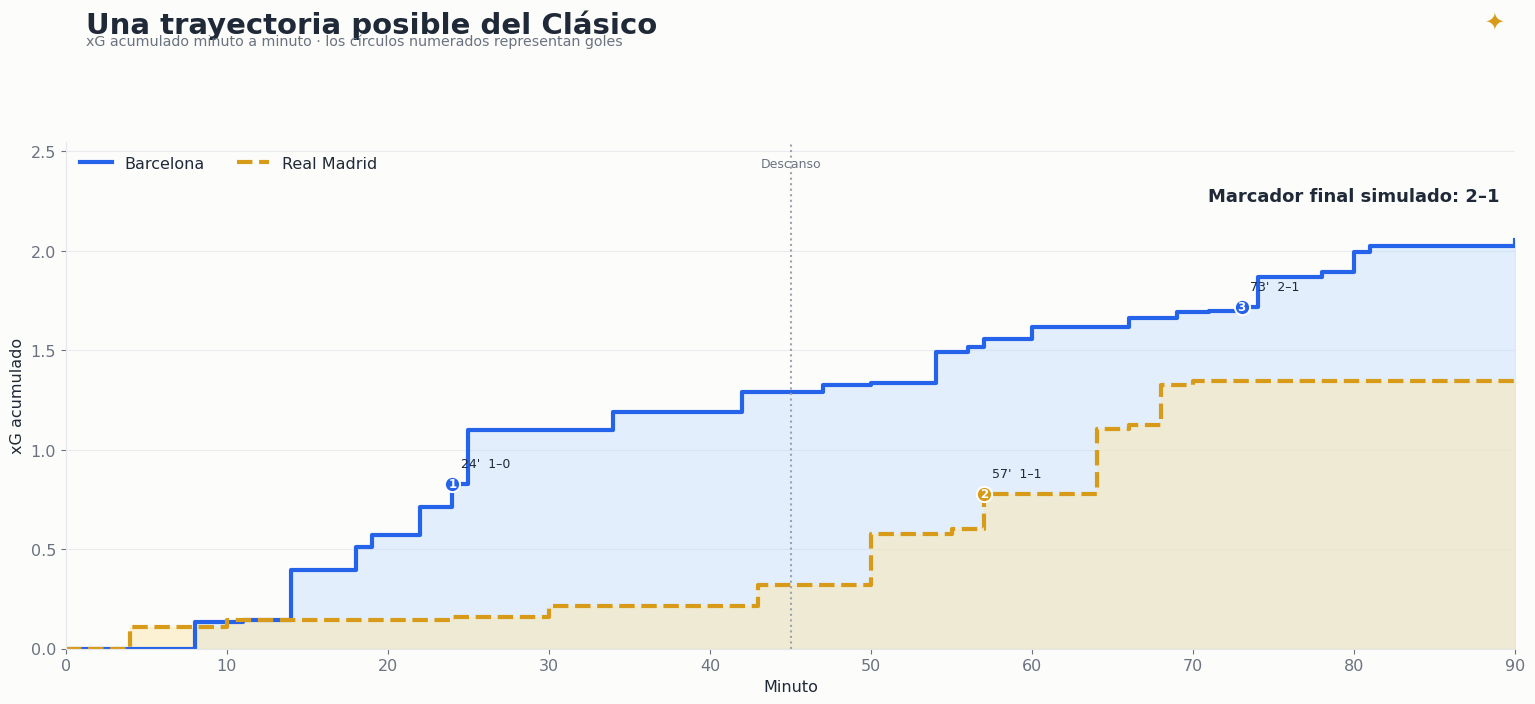

In [10]:
asset_path = ASSET_DIR / "monte_carlo_clasico_timeline.png"

fig, ax = plt.subplots(figsize=(15.5, 7.2))
minutes = np.r_[0, trace["minute"].to_numpy()]
home_cum = np.r_[0, trace["home_xg"].to_numpy()]
away_cum = np.r_[0, trace["away_xg"].to_numpy()]

ax.step(minutes, home_cum, where="post", color=BLUE, lw=3.0, label="Barcelona")
ax.step(minutes, away_cum, where="post", color=GOLD, lw=3.0, linestyle="--", label="Real Madrid")
ax.fill_between(minutes, home_cum, step="post", color=BLUE_LIGHT, alpha=0.42)
ax.fill_between(minutes, away_cum, step="post", color=GOLD_LIGHT, alpha=0.48)

for number, (minute, team, home_score, away_score) in enumerate(representative["goals"], start=1):
    column = "home_xg" if team == "Barcelona" else "away_xg"
    y_value = float(trace.loc[trace["minute"] == minute, column].iloc[0])
    color = BLUE if team == "Barcelona" else GOLD
    ax.scatter(minute, y_value, s=120, color=color, edgecolor="white", linewidth=1.4, zorder=4)
    ax.text(
        minute, y_value, str(number), color="white", ha="center", va="center",
        fontsize=8.5, fontweight="bold", zorder=5,
    )
    ax.annotate(
        f"{minute}'  {home_score}–{away_score}", (minute, y_value), xytext=(6, 12),
        textcoords="offset points", fontsize=9, color=INK,
    )

ax.axvline(45, color=GREY, linestyle=":", lw=1.5)
y_max = max(home_cum[-1], away_cum[-1]) * 1.24
ax.text(45, y_max * 0.97, "Descanso", ha="center", va="top", color=MUTED, fontsize=9)
ax.set_xlim(0, 90)
ax.set_ylim(0, y_max)
ax.set_xlabel("Minuto")
ax.set_ylabel("xG acumulado")
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.text(
    89, y_max * 0.91,
    f"Marcador final simulado: {representative['home_goals']}–{representative['away_goals']}",
    ha="right", va="top", fontsize=13, fontweight="bold",
)
clean_axes(ax)

fig.suptitle(
    "Una trayectoria posible del Clásico",
    x=0.06, y=0.975, ha="left", fontsize=21, fontweight="bold", color=INK,
)
finish_chart(
    fig,
    "xG acumulado minuto a minuto · los círculos numerados representan goles",
    y=0.925,
)
plt.tight_layout(rect=(0, 0, 1, 0.88))
fig.savefig(asset_path, dpi=180, bbox_inches="tight", facecolor=PAPER)
plt.show()

## 3. Diez partidos sorteados al azar

Estas diez filas son una muestra reproducible de las 10,000 simulaciones. Sirven para ver la dispersión que se pierde cuando solo miramos el promedio.

In [11]:
random_ten = simulation.sample(n=10, random_state=SEED).copy()
random_ten = random_ten.assign(
    **{
        "Simulación": random_ten["sim_id"] + 1,
        "Goles Barcelona": random_ten["home_goals"],
        "Goles Real Madrid": random_ten["away_goals"],
        "xG Barcelona": random_ten["home_xg"].round(2),
        "xG Real Madrid": random_ten["away_xg"].round(2),
    }
)[["Simulación", "Goles Barcelona", "Goles Real Madrid", "xG Barcelona", "xG Real Madrid"]]

display(
    random_ten.reset_index(drop=True).style
    .format({"xG Barcelona": "{:.2f}", "xG Real Madrid": "{:.2f}"})
    .hide(axis="index")
)

Simulación,Goles Barcelona,Goles Real Madrid,xG Barcelona,xG Real Madrid
8161,5,2,2.77,3.07
4312,5,0,3.35,1.22
4208,5,2,4.27,1.51
8589,4,0,2.19,1.20
1472,2,1,1.82,0.91
9531,2,2,1.30,1.45
4862,0,4,2.51,2.03
3601,1,3,1.31,1.86
2225,3,2,1.83,1.38
4632,1,2,2.71,2.39


## 4. Cuotas después de 10,000 simulaciones

La **cuota justa** traduce los resultados del Monte Carlo a un precio sin margen. Para el 1X2 y el total de 3.5 goles se obtiene con la frecuencia de cada resultado.

En el **Asian Handicap**, las líneas de cuarto se dividen en dos apuestas vecinas. Por ejemplo, Barcelona `-0.75` reparte la mitad del importe en `-0.5` y la otra mitad en `-1.0`. Por eso el cálculo contempla ganancias completas, medias ganancias, devoluciones, medias pérdidas y pérdidas completas.

In [12]:
standard_probabilities = pd.Series({
    "Barcelona": probabilities["Barcelona"],
    "Empate": probabilities["Empate"],
    "Real Madrid": probabilities["Real Madrid"],
    "Más de 3.5": (simulation["total_goals"] > 3.5).mean(),
    "Menos de 3.5": (simulation["total_goals"] < 3.5).mean(),
}, name="Probabilidad del modelo")

standard_market_odds = pd.Series({
    "Barcelona": 1.87,
    "Empate": 4.33,
    "Real Madrid": 3.50,
    "Más de 3.5": 1.73,
    "Menos de 3.5": 2.10,
}, name="Cuota de mercado")

asian_markets = [
    ("Barcelona -1.25", "Barcelona", -1.25, 2.54),
    ("Real Madrid +1.25", "Real Madrid", 1.25, 1.52),
    ("Barcelona -0.75", "Barcelona", -0.75, 2.12),
    ("Real Madrid +0.75", "Real Madrid", 0.75, 1.81),
    ("Barcelona -0.25", "Barcelona", -0.25, 1.69),
    ("Real Madrid +0.25", "Real Madrid", 0.25, 2.22),
    ("Barcelona 0", "Barcelona", 0.0, 1.48),
    ("Real Madrid 0", "Real Madrid", 0.0, 2.85),
    ("Barcelona +0.25", "Barcelona", 0.25, 1.44),
    ("Real Madrid -0.25", "Real Madrid", -0.25, 2.88),
]

def handicap_legs(handicap):
    # Las líneas .25 y .75 reparten la apuesta entre las dos medias líneas vecinas.
    quarter_units = int(round(handicap * 4))
    if quarter_units % 2:
        return (handicap - 0.25, handicap + 0.25)
    return (handicap,)

def asian_handicap_metrics(team, handicap, market_price):
    goal_difference = (
        simulation["home_goals"].to_numpy() - simulation["away_goals"].to_numpy()
        if team == "Barcelona"
        else simulation["away_goals"].to_numpy() - simulation["home_goals"].to_numpy()
    )
    adjusted_margins = np.vstack([
        goal_difference + leg for leg in handicap_legs(handicap)
    ])
    win_share = (adjusted_margins > 0).mean(axis=0)
    loss_share = (adjusted_margins < 0).mean(axis=0)
    push_share = 1 - win_share - loss_share

    weighted_wins = win_share.mean()
    weighted_losses = loss_share.mean()
    weighted_pushes = push_share.mean()
    fair_price = 1 + weighted_losses / weighted_wins
    expected_return = weighted_wins * (market_price - 1) - weighted_losses
    return {
        "Cuota justa del modelo": fair_price,
        "Cuota de mercado": market_price,
        "Ventaja estimada": expected_return,
        "Peso ganador": weighted_wins,
        "Peso devolución": weighted_pushes,
        "Peso perdedor": weighted_losses,
    }

asian_results = pd.DataFrame({
    label: asian_handicap_metrics(team, handicap, price)
    for label, team, handicap, price in asian_markets
}).T

standard_table = pd.DataFrame({
    "Mercado": ["1X2", "1X2", "1X2", "Total 3.5", "Total 3.5"],
    "Selección": standard_probabilities.index,
    "Cuota justa del modelo": 1 / standard_probabilities.to_numpy(),
    "Cuota de mercado": standard_market_odds.to_numpy(),
})
asian_table = pd.DataFrame({
    "Mercado": "Asian Handicap",
    "Selección": asian_results.index,
    "Cuota justa del modelo": asian_results["Cuota justa del modelo"].to_numpy(),
    "Cuota de mercado": asian_results["Cuota de mercado"].to_numpy(),
})
odds_table = pd.concat([standard_table, asian_table], ignore_index=True)

assert np.isclose(standard_probabilities.loc[["Barcelona", "Empate", "Real Madrid"]].sum(), 1.0)
assert np.isclose(standard_probabilities["Más de 3.5"] + standard_probabilities["Menos de 3.5"], 1.0)
assert np.allclose(standard_table["Cuota justa del modelo"], 1 / standard_probabilities)
assert handicap_legs(-1.25) == (-1.5, -1.0)
assert handicap_legs(-0.75) == (-1.0, -0.5)
assert handicap_legs(-0.25) == (-0.5, 0.0)

display(
    odds_table.style
    .format({"Cuota justa del modelo": "{:.2f}", "Cuota de mercado": "{:.2f}"})
    .hide(axis="index")
)

Mercado,Selección,Cuota justa del modelo,Cuota de mercado
1X2,Barcelona,1.84,1.87
1X2,Empate,4.88,4.33
1X2,Real Madrid,3.99,3.50
Total 3.5,Más de 3.5,2.01,1.73
Total 3.5,Menos de 3.5,1.99,2.10
Asian Handicap,Barcelona -1.25,2.80,2.54
Asian Handicap,Real Madrid +1.25,1.55,1.52
Asian Handicap,Barcelona -0.75,2.06,2.12
Asian Handicap,Real Madrid +0.75,1.94,1.81
Asian Handicap,Barcelona -0.25,1.65,1.69


## 5. ¿Dónde ve ventaja el modelo?

La comparación se hace en términos de retorno esperado. En 1X2 y goles, una selección gana o pierde. En Asian Handicap, la misma fórmula respeta la parte de la apuesta que gana, se devuelve o pierde.

**Ventaja estimada = retorno medio por cada unidad apostada**

In [13]:
standard_edges = standard_probabilities * standard_market_odds - 1
asian_edges = asian_results["Ventaja estimada"]

advantage_table = odds_table.copy()
advantage_table["Ventaja estimada"] = np.r_[standard_edges.to_numpy(), asian_edges.to_numpy()]
advantage_table["Lectura"] = np.where(
    advantage_table["Ventaja estimada"] > 0,
    "Cuota con valor",
    "Cuota corta",
)

display(
    advantage_table.style
    .format({
        "Cuota justa del modelo": "{:.2f}",
        "Cuota de mercado": "{:.2f}",
        "Ventaja estimada": "{:+.1%}",
    })
    .map(
        lambda value: "color: #2563EB; font-weight: 700" if isinstance(value, (float, np.floating)) and value > 0 else "",
        subset=["Ventaja estimada"],
    )
    .hide(axis="index")
)

Mercado,Selección,Cuota justa del modelo,Cuota de mercado,Ventaja estimada,Lectura
1X2,Barcelona,1.84,1.87,+1.8%,Cuota con valor
1X2,Empate,4.88,4.33,-11.2%,Cuota corta
1X2,Real Madrid,3.99,3.50,-12.4%,Cuota corta
Total 3.5,Más de 3.5,2.01,1.73,-13.8%,Cuota corta
Total 3.5,Menos de 3.5,1.99,2.10,+5.3%,Cuota con valor
Asian Handicap,Barcelona -1.25,2.80,2.54,-8.4%,Cuota corta
Asian Handicap,Real Madrid +1.25,1.55,1.52,-1.9%,Cuota corta
Asian Handicap,Barcelona -0.75,2.06,2.12,+2.6%,Cuota con valor
Asian Handicap,Real Madrid +0.75,1.94,1.81,-6.1%,Cuota corta
Asian Handicap,Barcelona -0.25,1.65,1.69,+2.3%,Cuota con valor


**Cuotas de mercado utilizadas**

- 1X2: Barcelona **1.87**, empate **4.33**, Real Madrid **3.50**.
- Total 3.5: más **1.73**, menos **2.10**.
- Asian Handicap: Barcelona `-1.25` **2.54**, `-0.75` **2.12**, `-0.25` **1.69**, `0` **1.48**, `+0.25` **1.44**.
- Asian Handicap: Real Madrid `+1.25` **1.52**, `+0.75` **1.81**, `+0.25` **2.22**, `0` **2.85**, `-0.25` **2.88**.

Las cuotas de cuarto se valoran como dos medias apuestas; no se convierten en una probabilidad binaria de ganar.

## 6. El resultado real

Ahora sí podemos contrastar el modelo con lo que ocurrió.

In [14]:
actual_home, actual_away = 4, 3
barcelona_edge = float(standard_edges["Barcelona"])

def actual_asian_profit(team, handicap, price):
    goal_difference = actual_home - actual_away if team == "Barcelona" else actual_away - actual_home
    profits = []
    for leg in handicap_legs(handicap):
        adjusted_margin = goal_difference + leg
        profits.append(price - 1 if adjusted_margin > 0 else 0 if adjusted_margin == 0 else -1)
    return float(np.mean(profits))

barcelona_075_profit = actual_asian_profit("Barcelona", -0.75, 2.12)
barcelona_025_profit = actual_asian_profit("Barcelona", -0.25, 1.69)
barcelona_dnb_profit = actual_asian_profit("Barcelona", 0.0, 1.48)
barcelona_plus_profit = actual_asian_profit("Barcelona", 0.25, 1.44)

display(Markdown(
    f"El partido terminó **Barcelona 4–3 Real Madrid**. "
    f"El modelo tenía al Barcelona como favorito y su cuota de **1.87** ofrecía una "
    f"ventaja estimada de **{barcelona_edge:+.1%}**: esa selección ganó. "
    "También detectó valor en cuatro líneas de Barcelona del Asian Handicap. Con el margen de un gol, "
    f"Barcelona `-0.75` produjo media ganancia y media devolución (**{barcelona_075_profit:+.2f} unidades**); "
    f"`-0.25` (**{barcelona_025_profit:+.2f}**), `0` (**{barcelona_dnb_profit:+.2f}**) y `+0.25` "
    f"(**{barcelona_plus_profit:+.2f}**) ganaron por completo. Como contrapeso, el menos de 3.5 también aparecía "
    "con valor y perdió. Una ventaja positiva describe un precio atractivo a largo plazo; no garantiza un partido individual."
))

El partido terminó **Barcelona 4–3 Real Madrid**. El modelo tenía al Barcelona como favorito y su cuota de **1.87** ofrecía una ventaja estimada de **+1.8%**: esa selección ganó. También detectó valor en cuatro líneas de Barcelona del Asian Handicap. Con el margen de un gol, Barcelona `-0.75` produjo media ganancia y media devolución (**+0.56 unidades**); `-0.25` (**+0.69**), `0` (**+0.48**) y `+0.25` (**+0.44**) ganaron por completo. Como contrapeso, el menos de 3.5 también aparecía con valor y perdió. Una ventaja positiva describe un precio atractivo a largo plazo; no garantiza un partido individual.

### Lectura final

El Monte Carlo no intenta adivinar un único marcador: convierte miles de futuros posibles en precios comparables y permite valorar mercados con liquidaciones distintas. En este Clásico, el modelo encontraba una pequeña ventaja en la victoria del Barcelona. El resultado fue favorable, pero la calidad del modelo se evalúa en una muestra grande de partidos, no por una sola apuesta.

In [15]:
repeat_a = simulate_match(137)
repeat_b = simulate_match(137)
assert repeat_a == repeat_b
assert asset_path.exists() and asset_path.stat().st_size > 10_000
assert list(random_ten.columns) == [
    "Simulación", "Goles Barcelona", "Goles Real Madrid", "xG Barcelona", "xG Real Madrid"
]
assert standard_market_odds.to_dict() == {
    "Barcelona": 1.87, "Empate": 4.33, "Real Madrid": 3.50,
    "Más de 3.5": 1.73, "Menos de 3.5": 2.10,
}
assert {label: price for label, _, _, price in asian_markets} == {
    "Barcelona -1.25": 2.54, "Real Madrid +1.25": 1.52,
    "Barcelona -0.75": 2.12, "Real Madrid +0.75": 1.81,
    "Barcelona -0.25": 1.69, "Real Madrid +0.25": 2.22,
    "Barcelona 0": 1.48, "Real Madrid 0": 2.85,
    "Barcelona +0.25": 1.44, "Real Madrid -0.25": 2.88,
}
assert np.isclose(asian_results.loc["Barcelona -1.25", "Peso ganador"] + asian_results.loc["Barcelona -1.25", "Peso devolución"] + asian_results.loc["Barcelona -1.25", "Peso perdedor"], 1.0)
for _, result in asian_results.iterrows():
    assert np.isclose(
        result["Peso ganador"] * (result["Cuota justa del modelo"] - 1)
        - result["Peso perdedor"],
        0.0,
    )
assert np.isclose(actual_asian_profit("Barcelona", -1.25, 2.54), -0.5)
assert np.isclose(actual_asian_profit("Real Madrid", 1.25, 1.52), 0.26)
assert np.isclose(actual_asian_profit("Barcelona", -0.75, 2.12), 0.56)
assert np.isclose(actual_asian_profit("Real Madrid", 0.75, 1.81), -0.5)
assert np.isclose(actual_asian_profit("Barcelona", -0.25, 1.69), 0.69)
assert np.isclose(actual_asian_profit("Barcelona", 0.0, 1.48), 0.48)